In [1]:
import importlib.util
import sys
from datetime import date
import pandas as pd
import numpy as np
from typing import Dict, Literal, Optional
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import os
from pathlib import Path
from src.dataloading import EpiDataLoader

wissdaten_dir    = os.environ.get('TMPDIR') +'/wissdaten/'
data_env         = os.path.join(wissdaten_dir, 'ZKI-PH4/deschrijvers_wissdaten/data')

data_module      = module_path = data_env + "/__init__.py"
spec = importlib.util.spec_from_file_location("data", module_path)
module = importlib.util.module_from_spec(spec)
sys.modules["data"] = module
spec.loader.exec_module(module)

from data.visuals import *
colors_dict = {}
colors_dict['context']    = hexcodes['sky blue']
colors_dict['future']     = hexcodes['soft red']
colors_dict['predictions']= hexcodes['moss green']

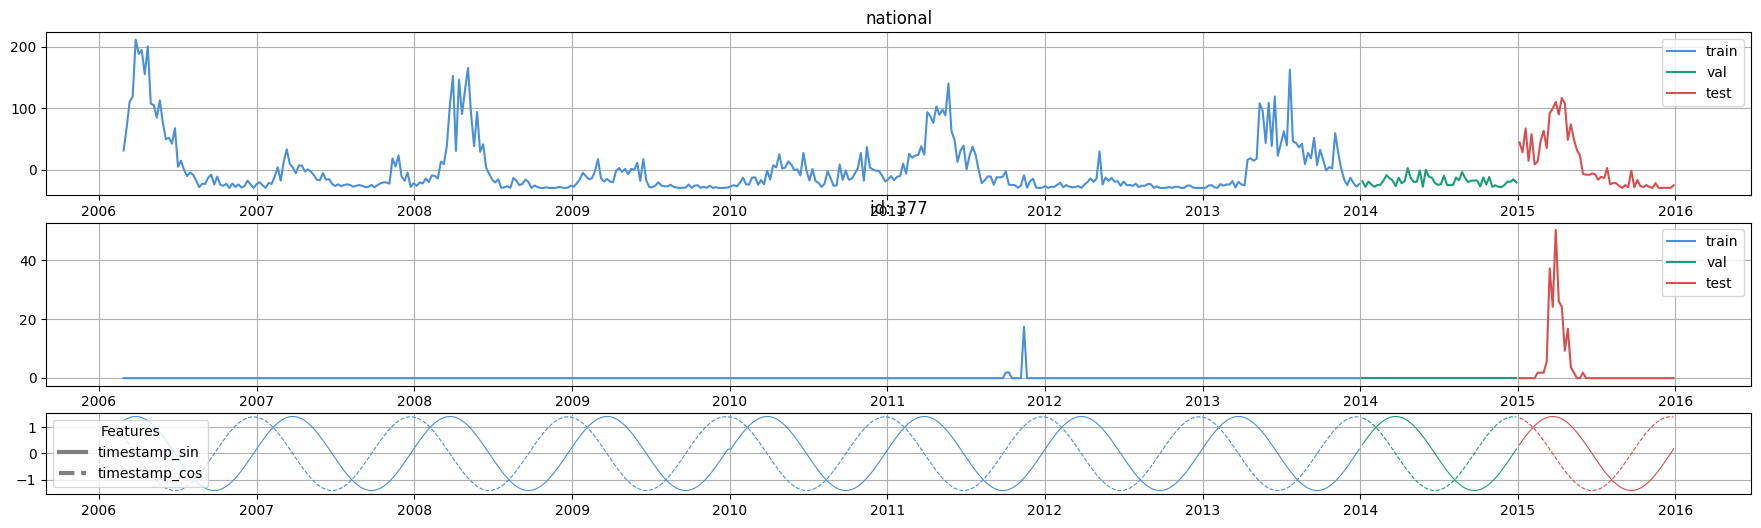

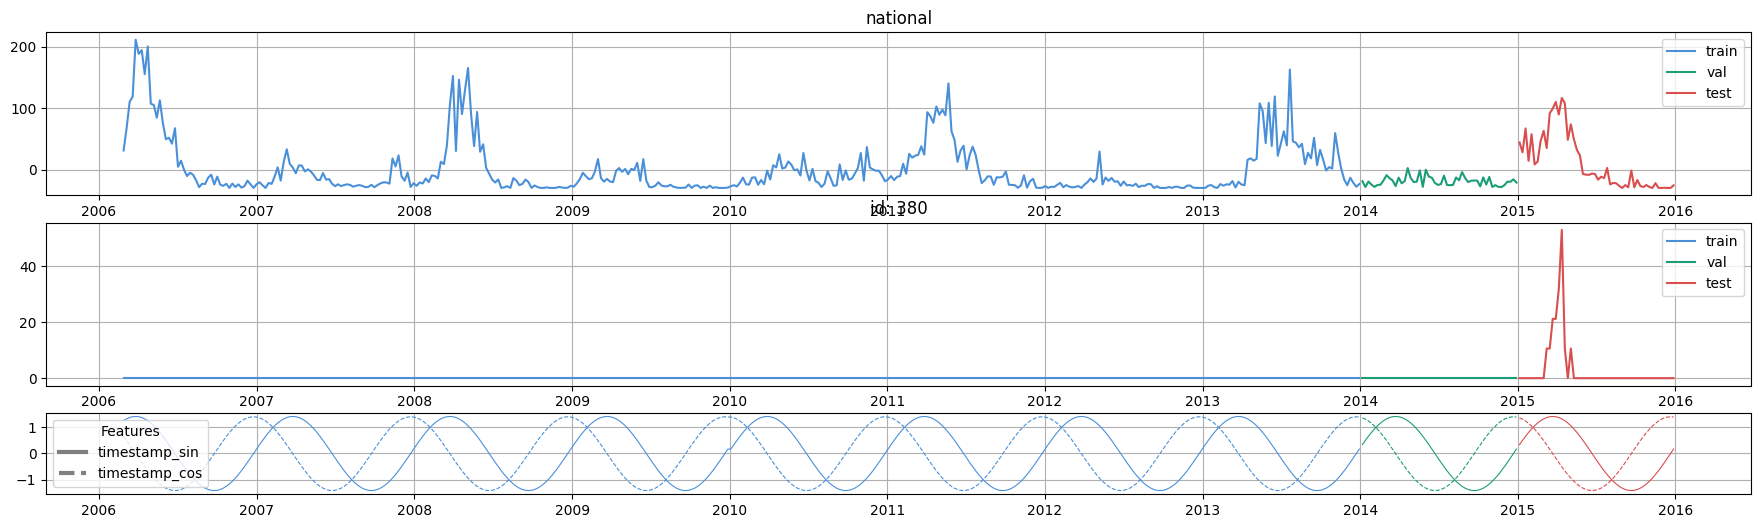

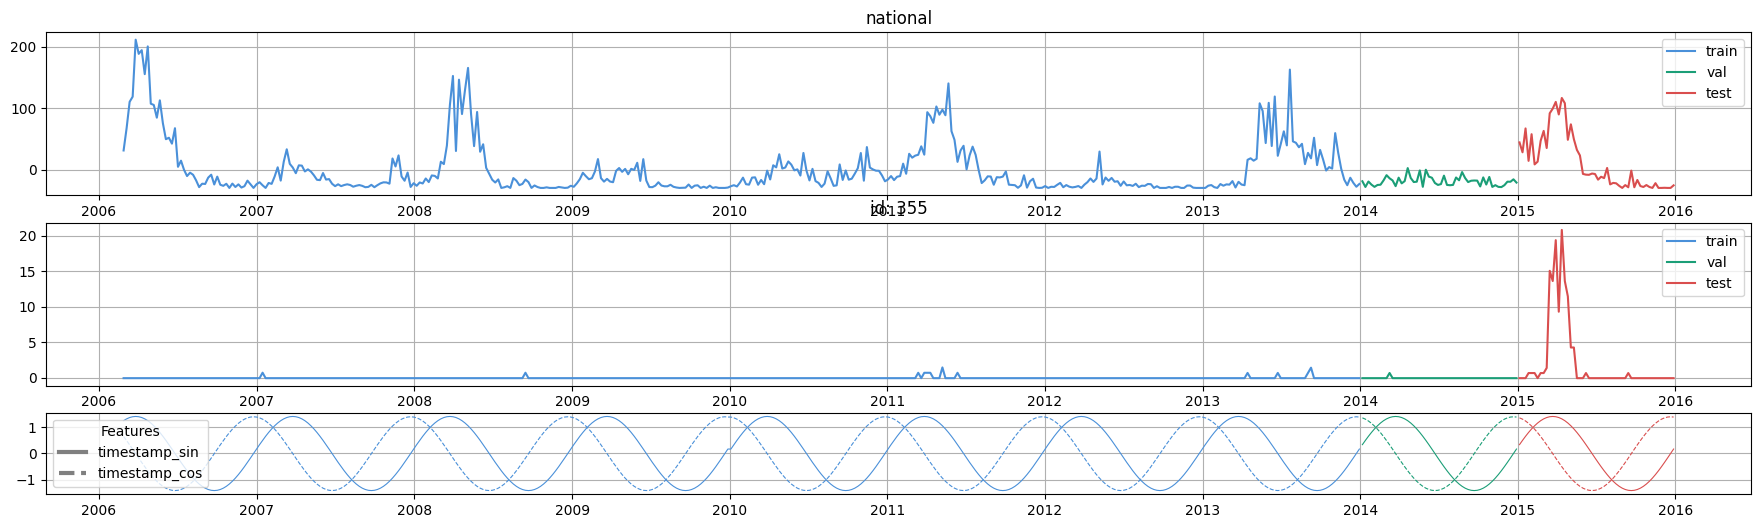

In [42]:
epidata_lag1 = EpiDataLoader(disease_name = 'measles', min_date = ' 2006-01-01', data_env_dir = data_env, max_date = '2016-01-01')
epidata_lag1.add_time_features()
epidata_lag1.normalize('2014-01-01','2015-01-01', method = 'zscore')
epidata_lag1.add_lagged_features(lags = range(1,9))
epidata_lag1.split_data()
epidata_lag1.preview(377)
epidata_lag1.preview(380)
epidata_lag1.preview(355)

epidata_lag4 = EpiDataLoader(disease_name = 'measles', min_date = ' 2006-01-01', data_env_dir = data_env, max_date = '2016-01-01')
epidata_lag4.add_time_features()
epidata_lag4.normalize('2014-01-01','2015-01-01', method = 'zscore')
epidata_lag4.add_lagged_features(lags = range(4,9))
epidata_lag4.split_data()


## XGB

[0]	train-rmse:0.98920	val-rmse:0.35070
[20]	train-rmse:0.76030	val-rmse:0.33872
[38]	train-rmse:0.66490	val-rmse:0.34352
[0]	train-rmse:0.99610	val-rmse:0.35127
[20]	train-rmse:0.85755	val-rmse:0.35123
[29]	train-rmse:0.82385	val-rmse:0.35328


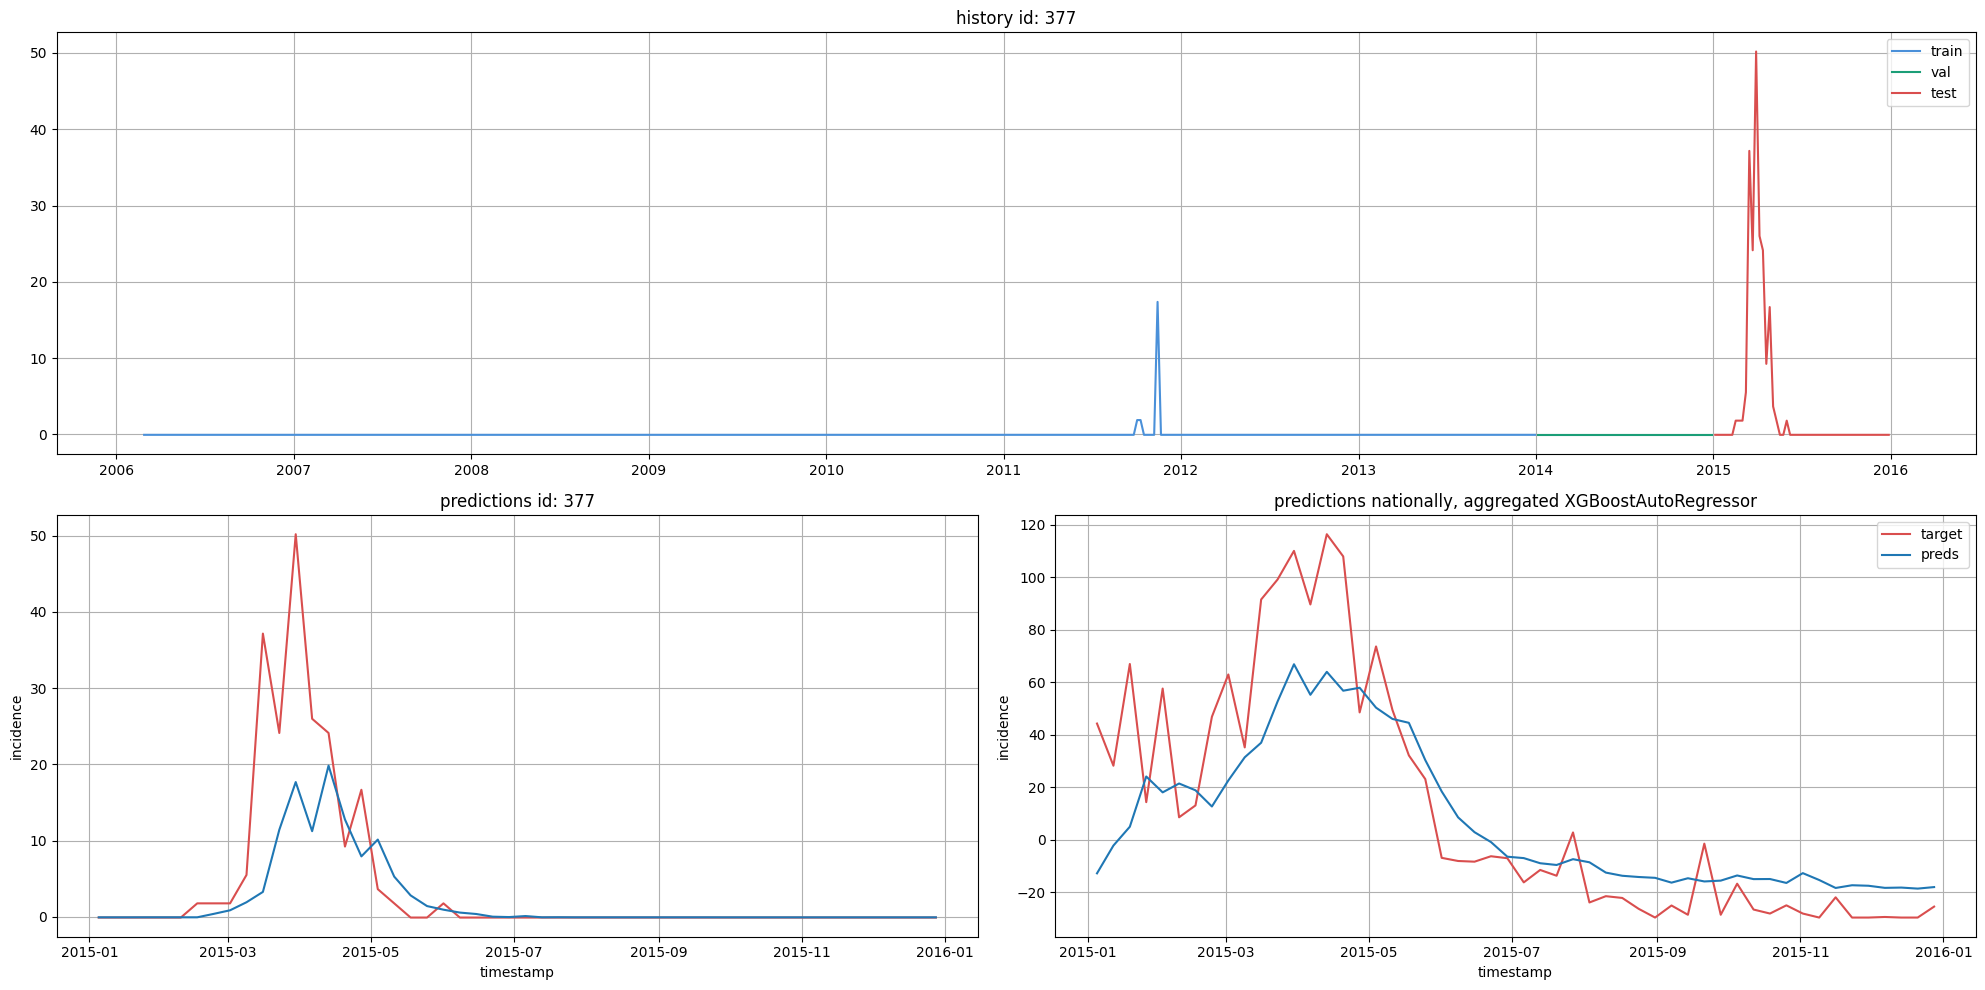

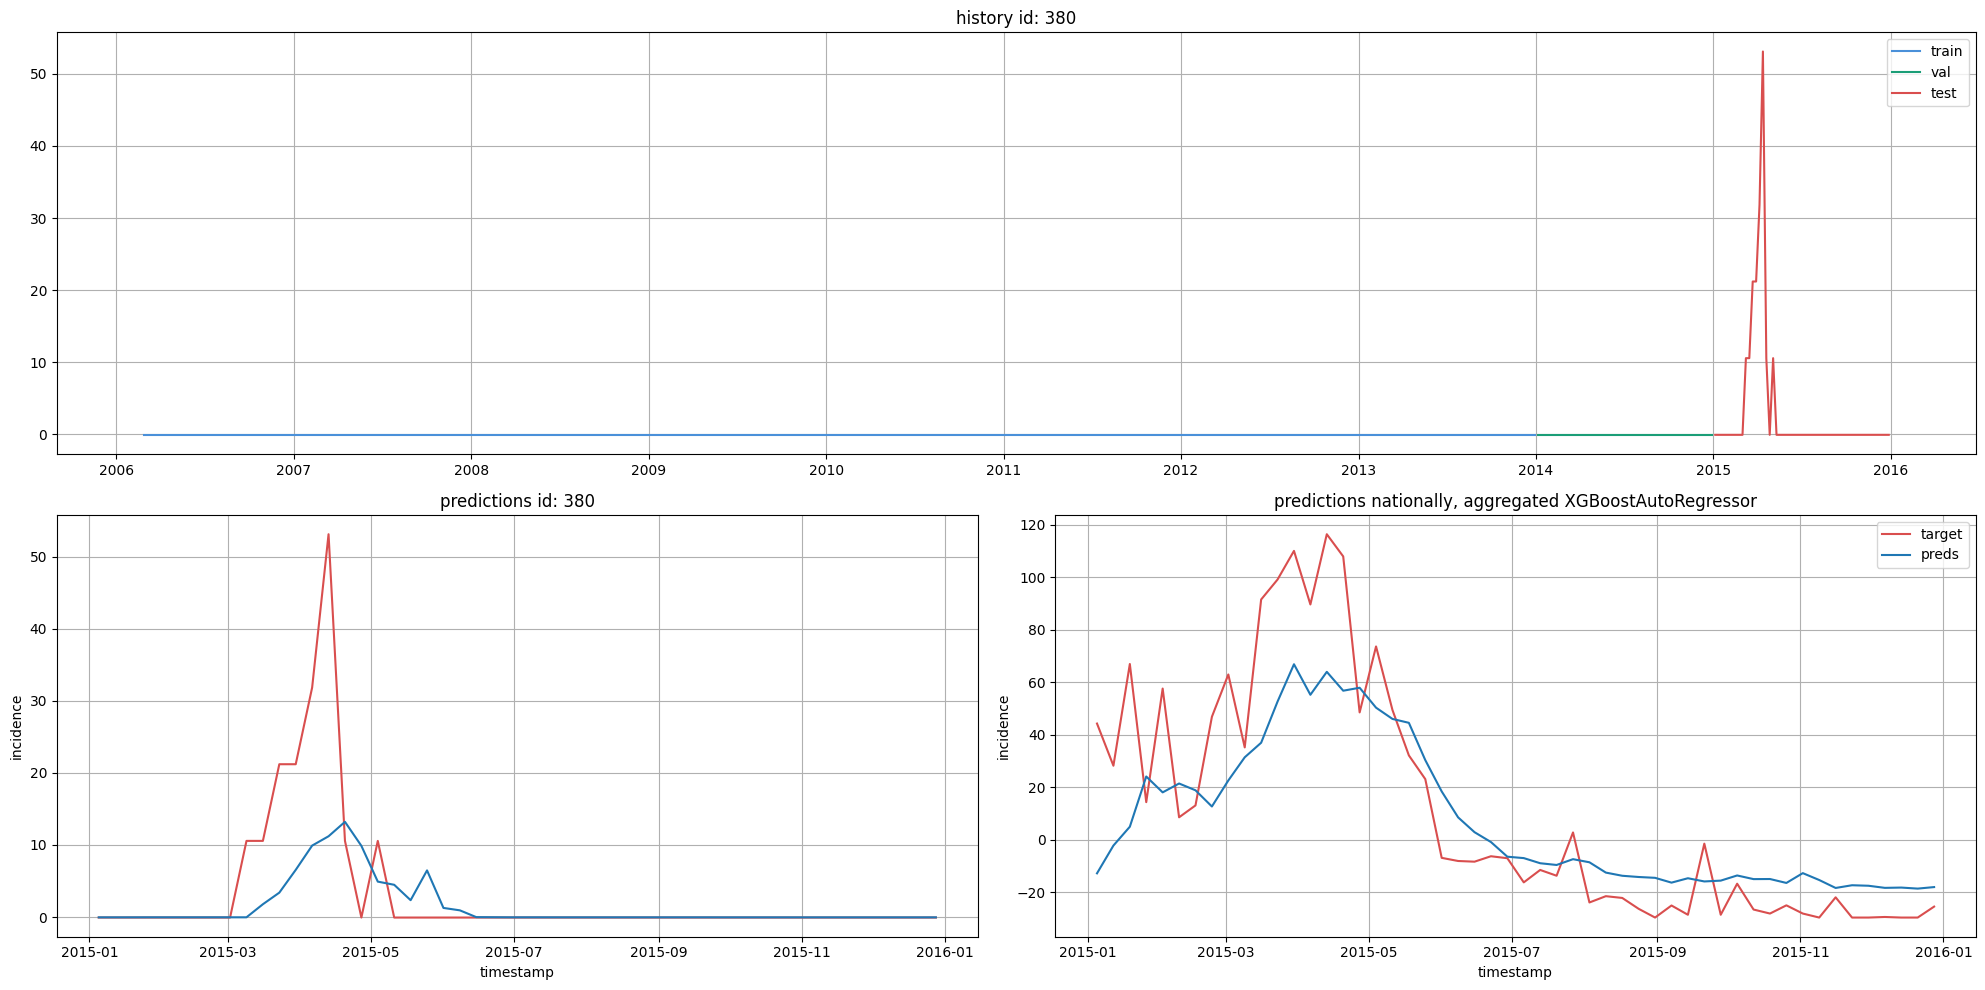

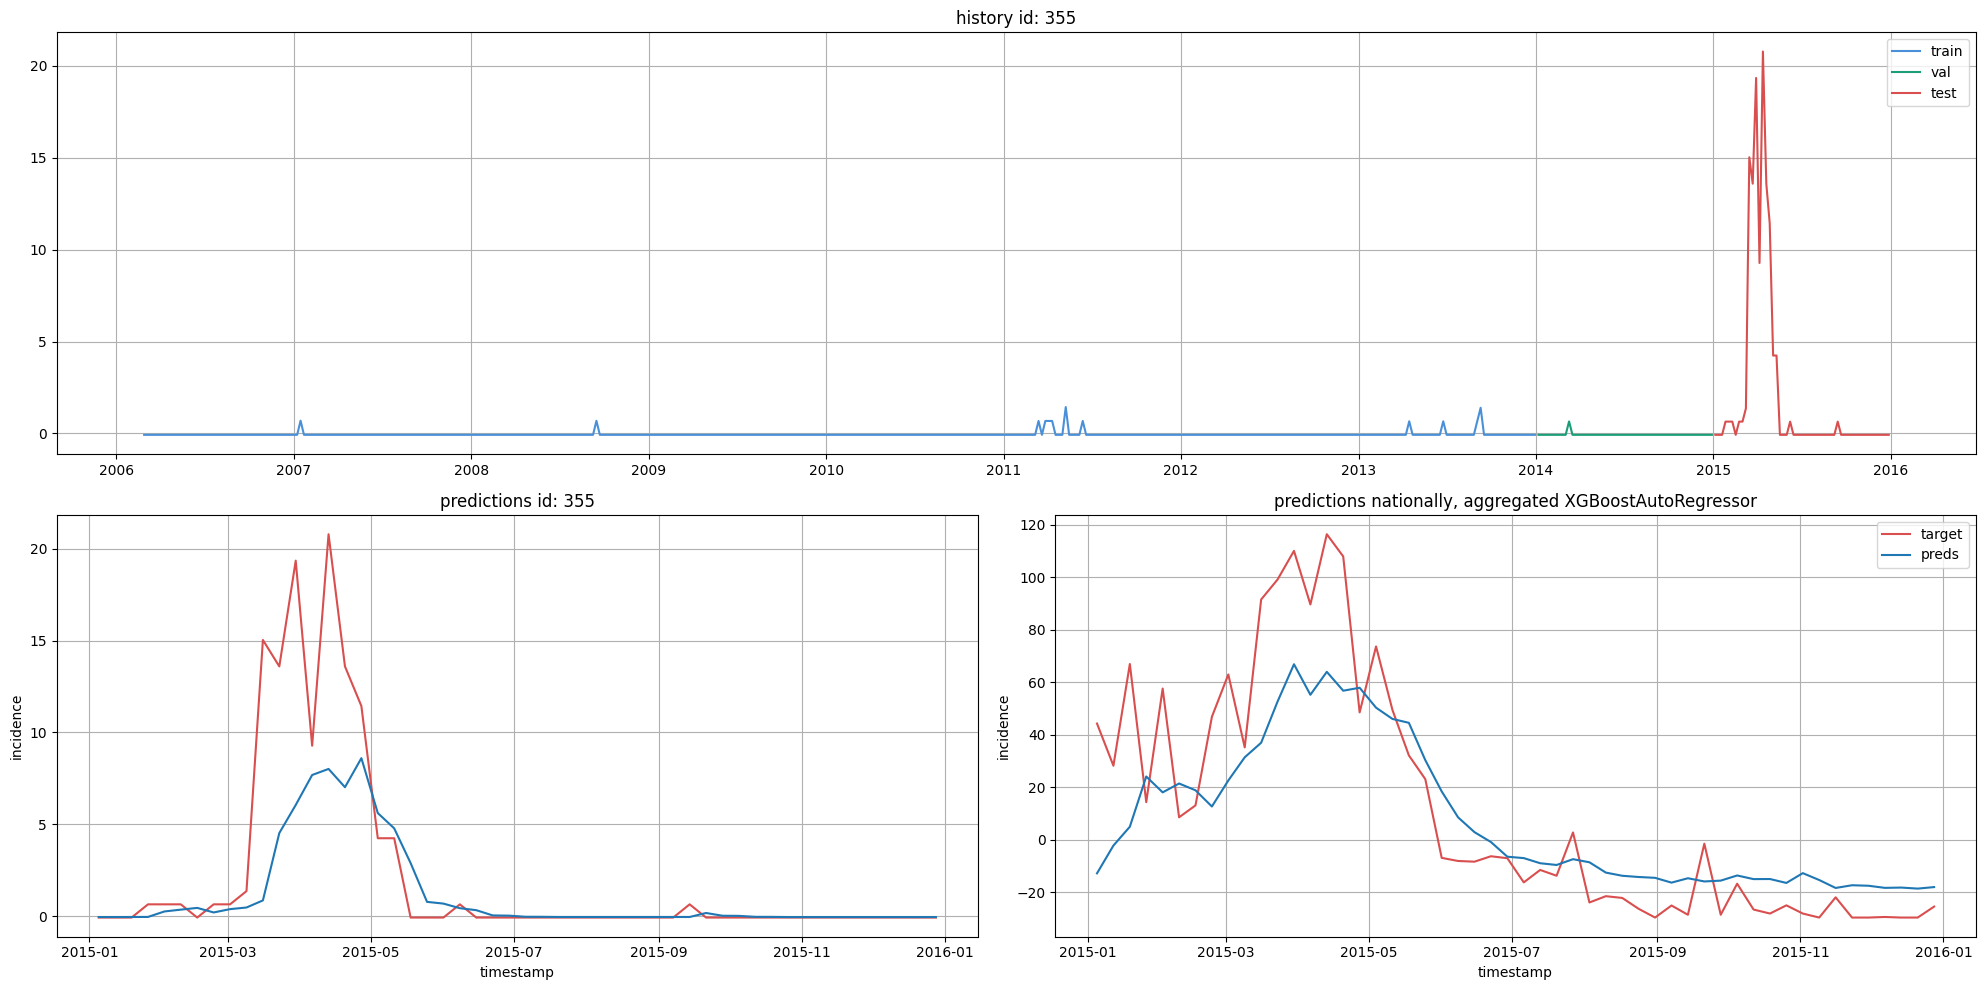

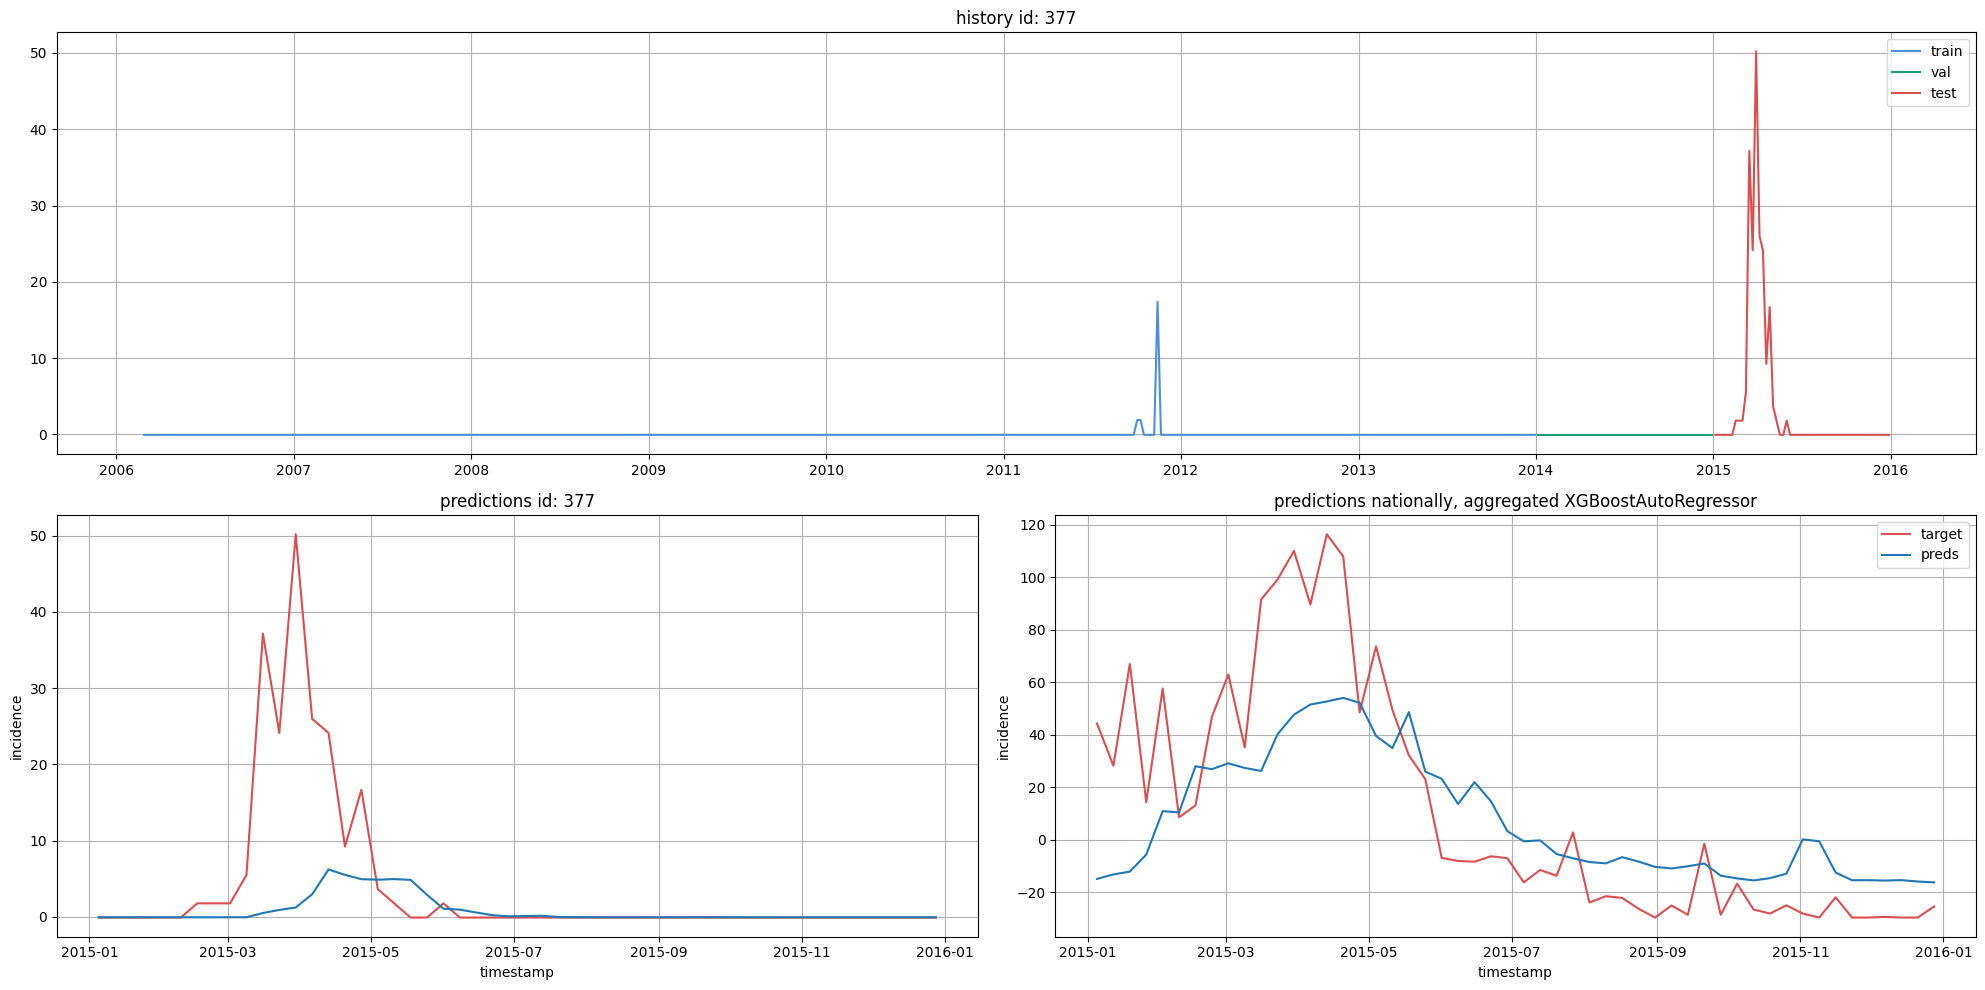

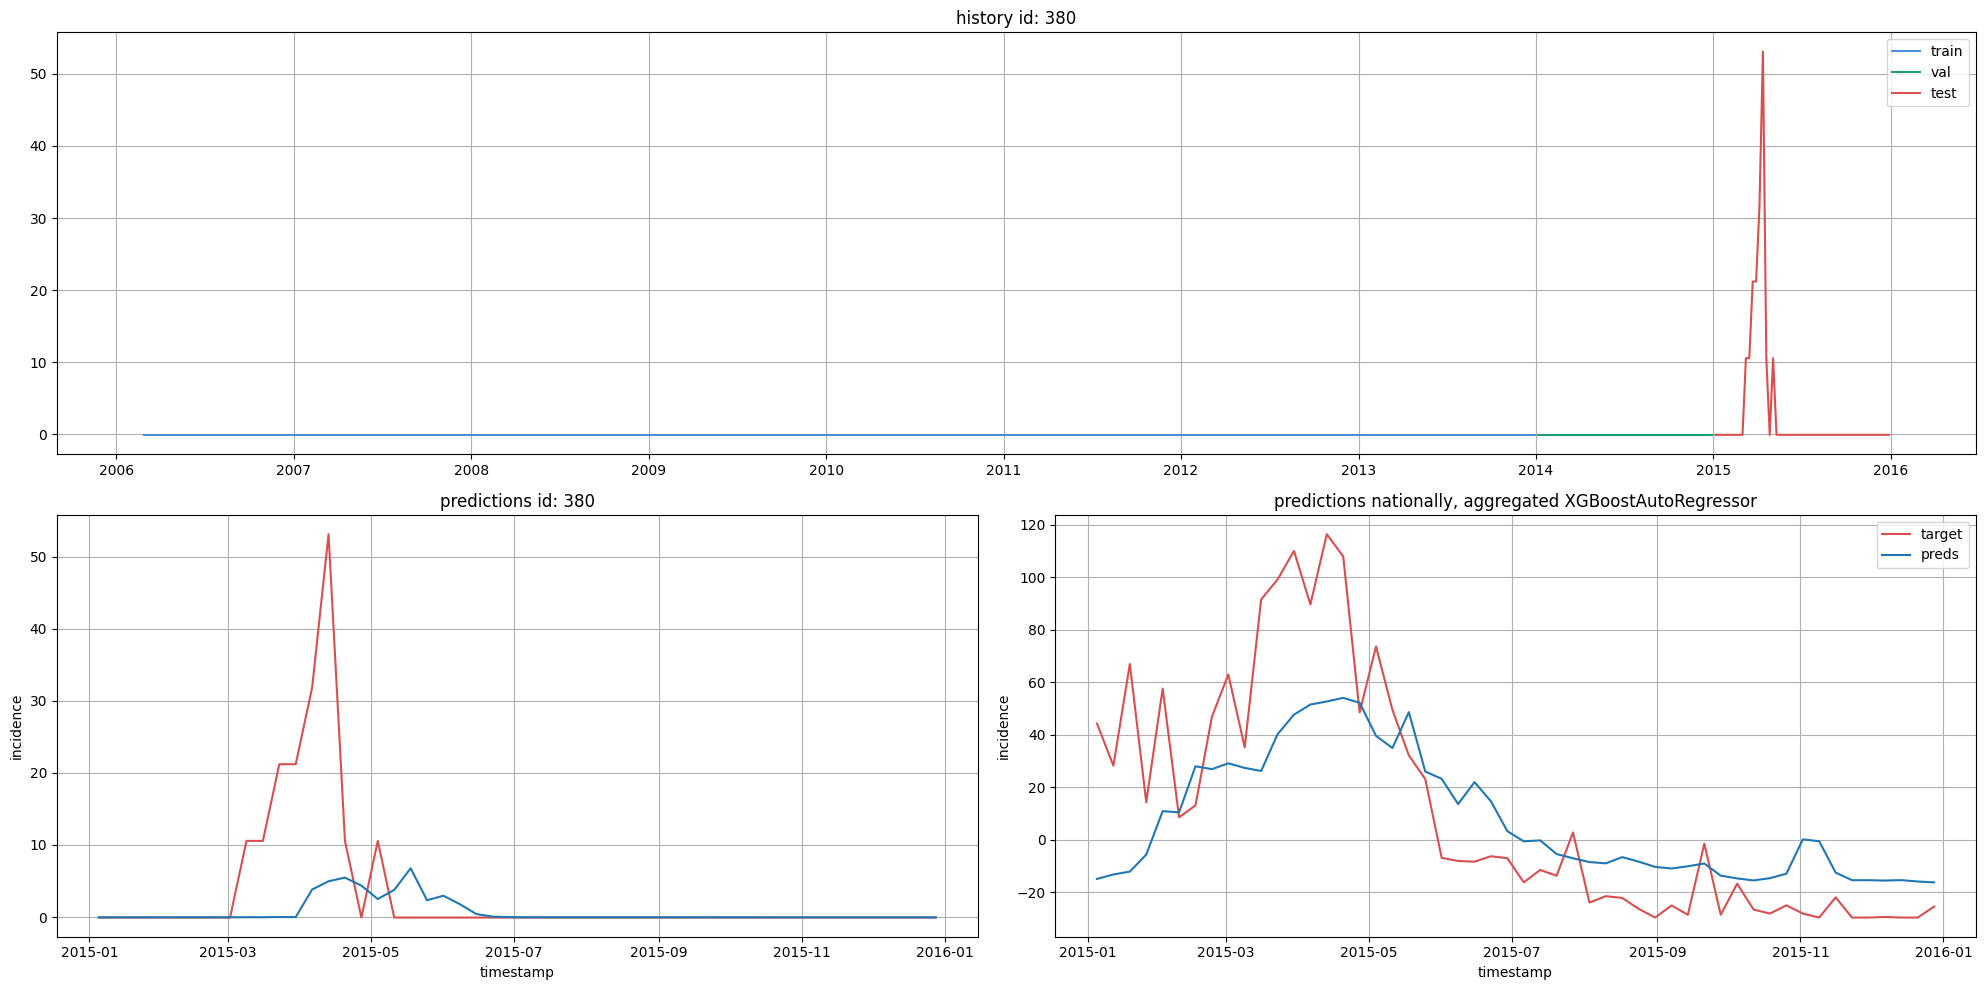

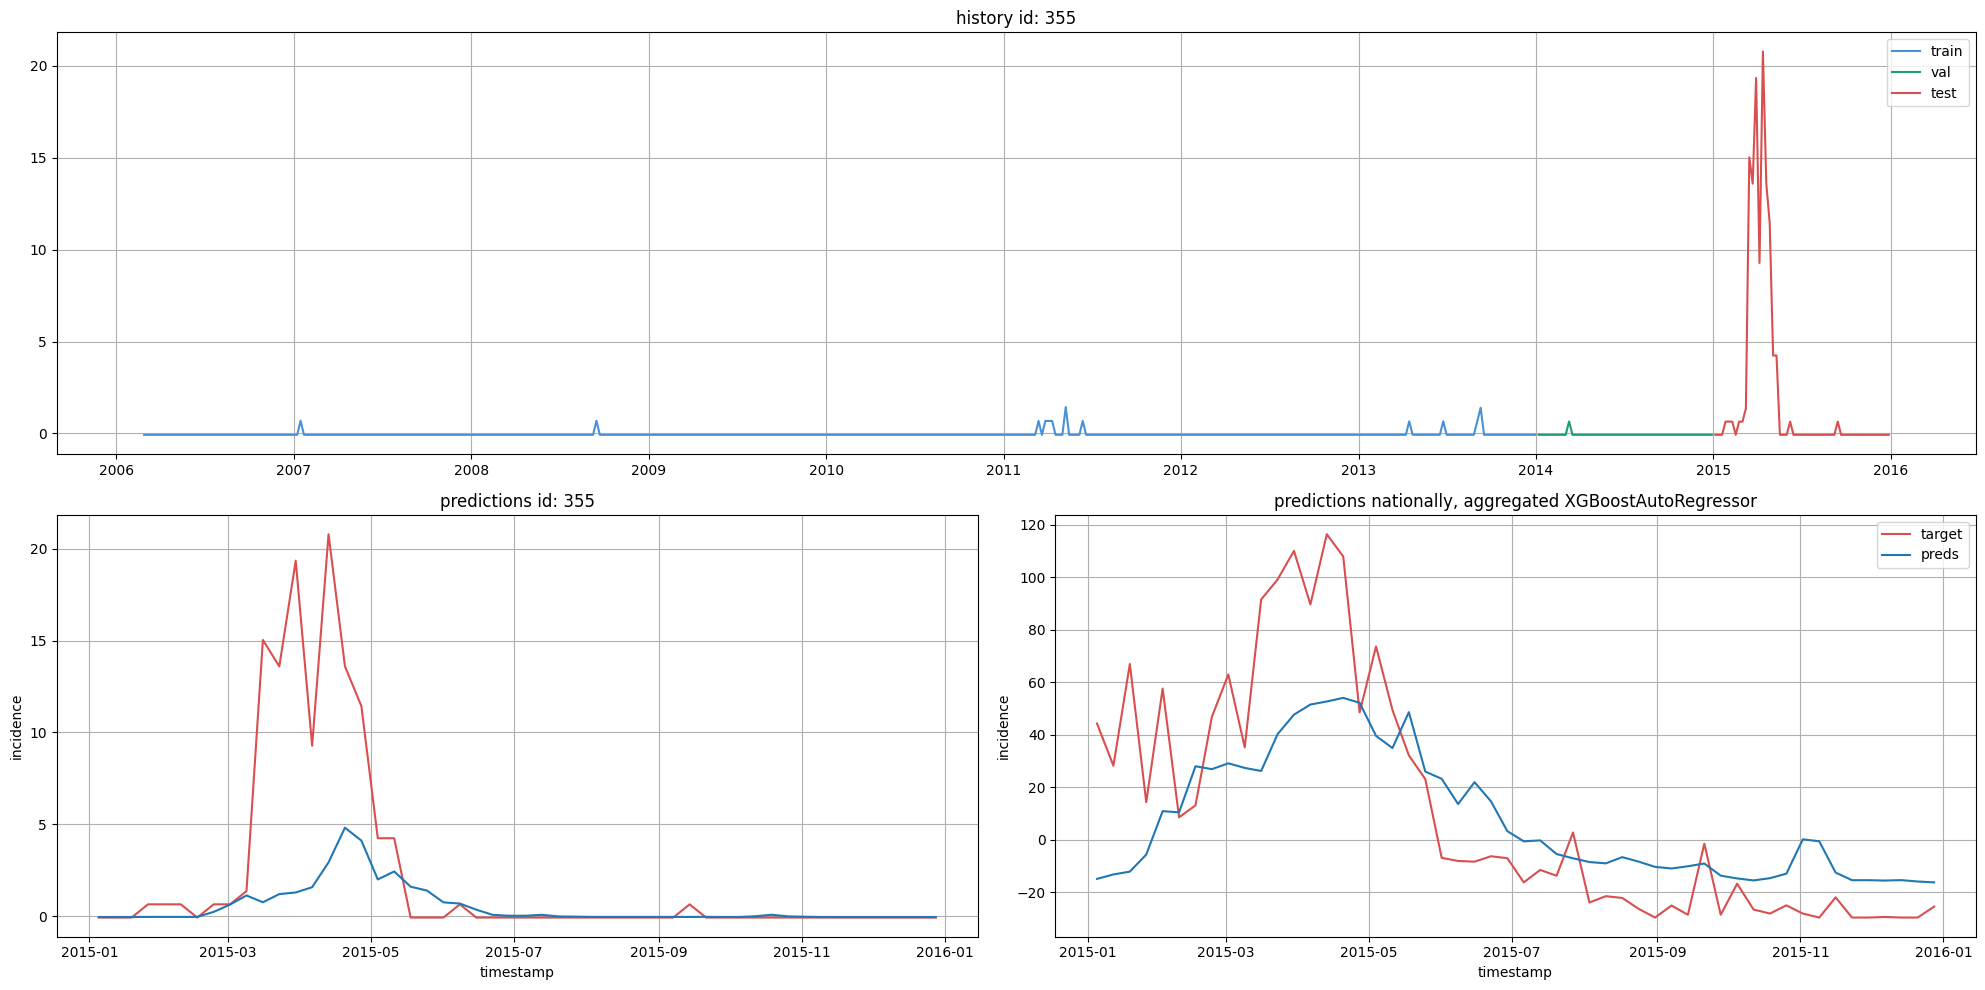

In [44]:
from src.models.xgboostautoregressor import XGBoostAutoRegressor

xgb_model = XGBoostAutoRegressor(epidata_lag1)
xgb_model.forecast()
xgb_model.show_forecasts(377)
xgb_model.show_forecasts(380)
xgb_model.show_forecasts(355)

xgb_model = XGBoostAutoRegressor(epidata_lag4)
xgb_model.forecast()
xgb_model.show_forecasts(377)
xgb_model.show_forecasts(380)
xgb_model.show_forecasts(355)

# GNN

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/projects/influenza/src/dataloading/gnndataloader.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_sa

Epoch 0 train MSE: 42.8737, val MSE: 1.1528 ✓ (new best)
Epoch 1 train MSE: 40.9906, val MSE: 1.2865 (patience: 1/15)
Epoch 2 train MSE: 39.8623, val MSE: 1.1390 ✓ (new best)
Epoch 3 train MSE: 39.0280, val MSE: 1.0670 ✓ (new best)
Epoch 4 train MSE: 38.4648, val MSE: 1.0516 ✓ (new best)
Epoch 5 train MSE: 38.0507, val MSE: 1.0667 (patience: 1/15)
Epoch 6 train MSE: 37.7140, val MSE: 1.0924 (patience: 2/15)
Epoch 7 train MSE: 37.4229, val MSE: 1.1224 (patience: 3/15)
Epoch 8 train MSE: 37.1661, val MSE: 1.1495 (patience: 4/15)
Epoch 9 train MSE: 36.9249, val MSE: 1.1777 (patience: 5/15)
Epoch 10 train MSE: 36.7016, val MSE: 1.2032 (patience: 6/15)
Epoch 11 train MSE: 36.4868, val MSE: 1.2295 (patience: 7/15)
Epoch 12 train MSE: 36.2824, val MSE: 1.2538 (patience: 8/15)
Epoch 13 train MSE: 36.0863, val MSE: 1.2776 (patience: 9/15)
Epoch 14 train MSE: 35.9009, val MSE: 1.2968 (patience: 10/15)
Epoch 15 train MSE: 35.7169, val MSE: 1.2683 (patience: 11/15)
Epoch 16 train MSE: 35.5718, val

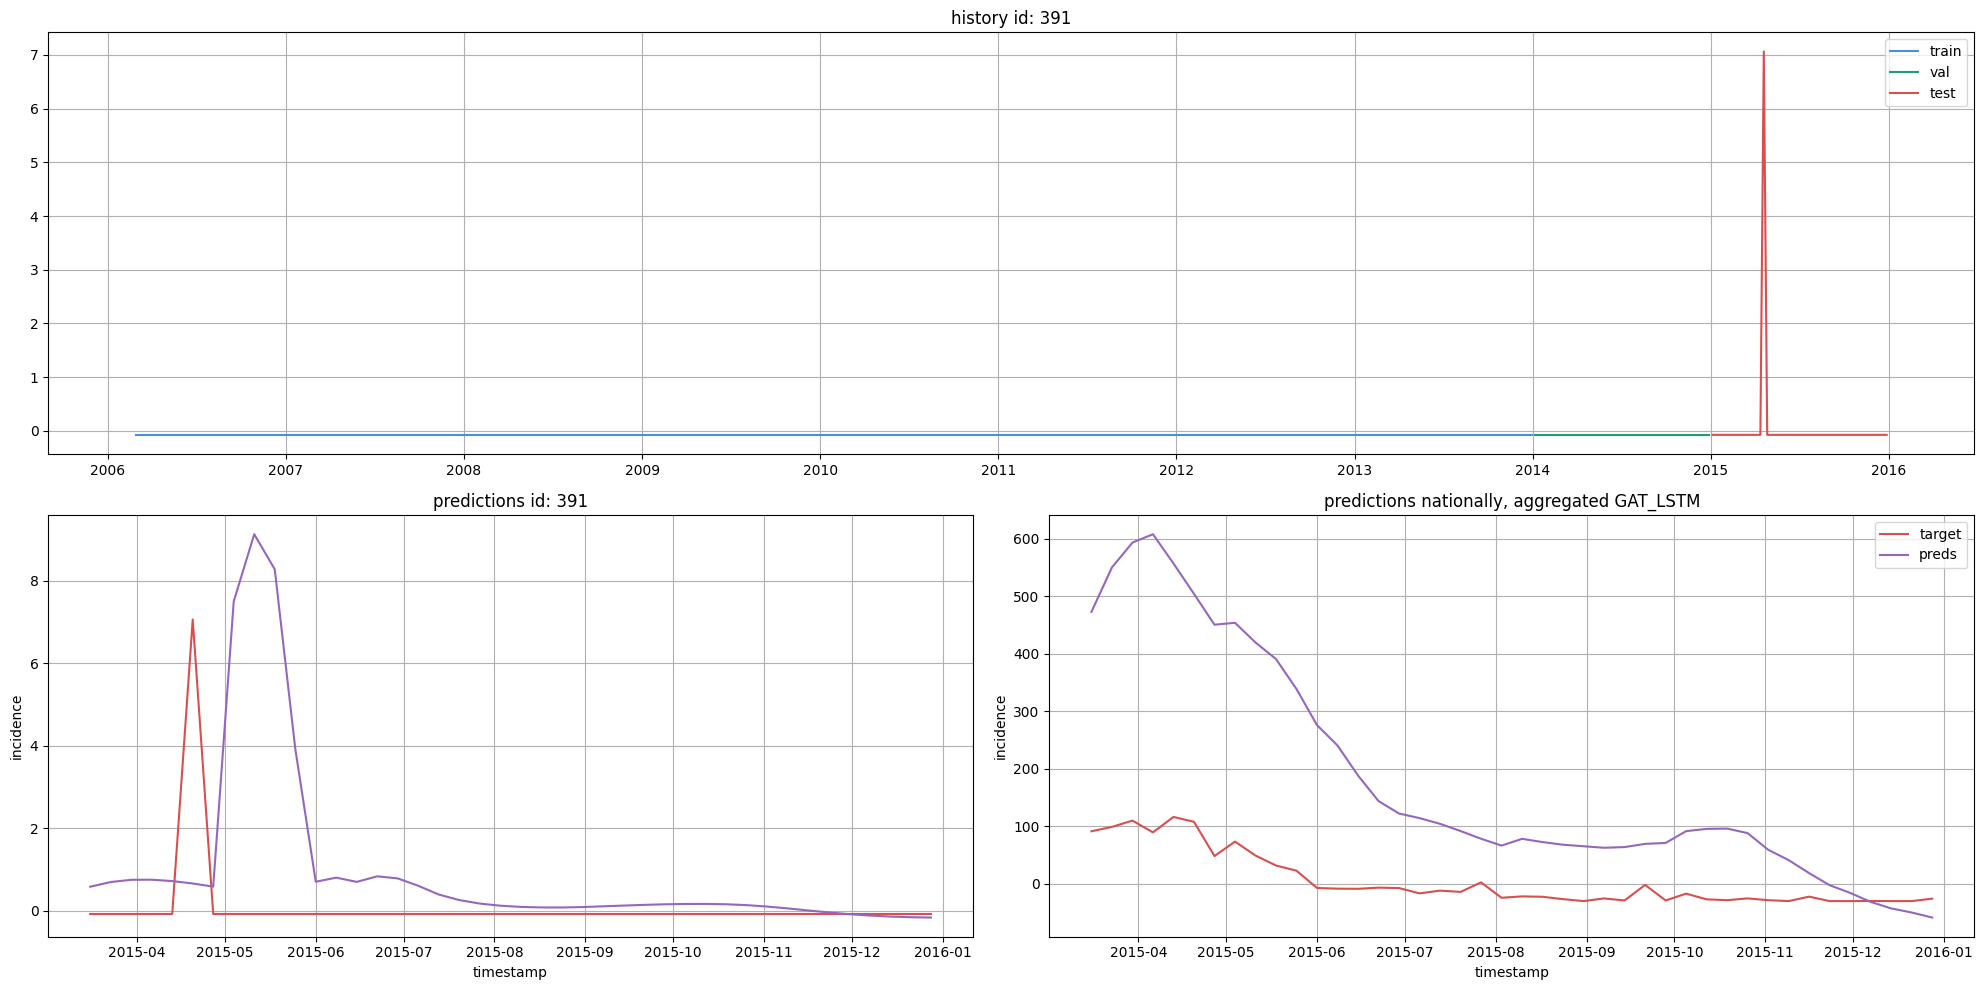

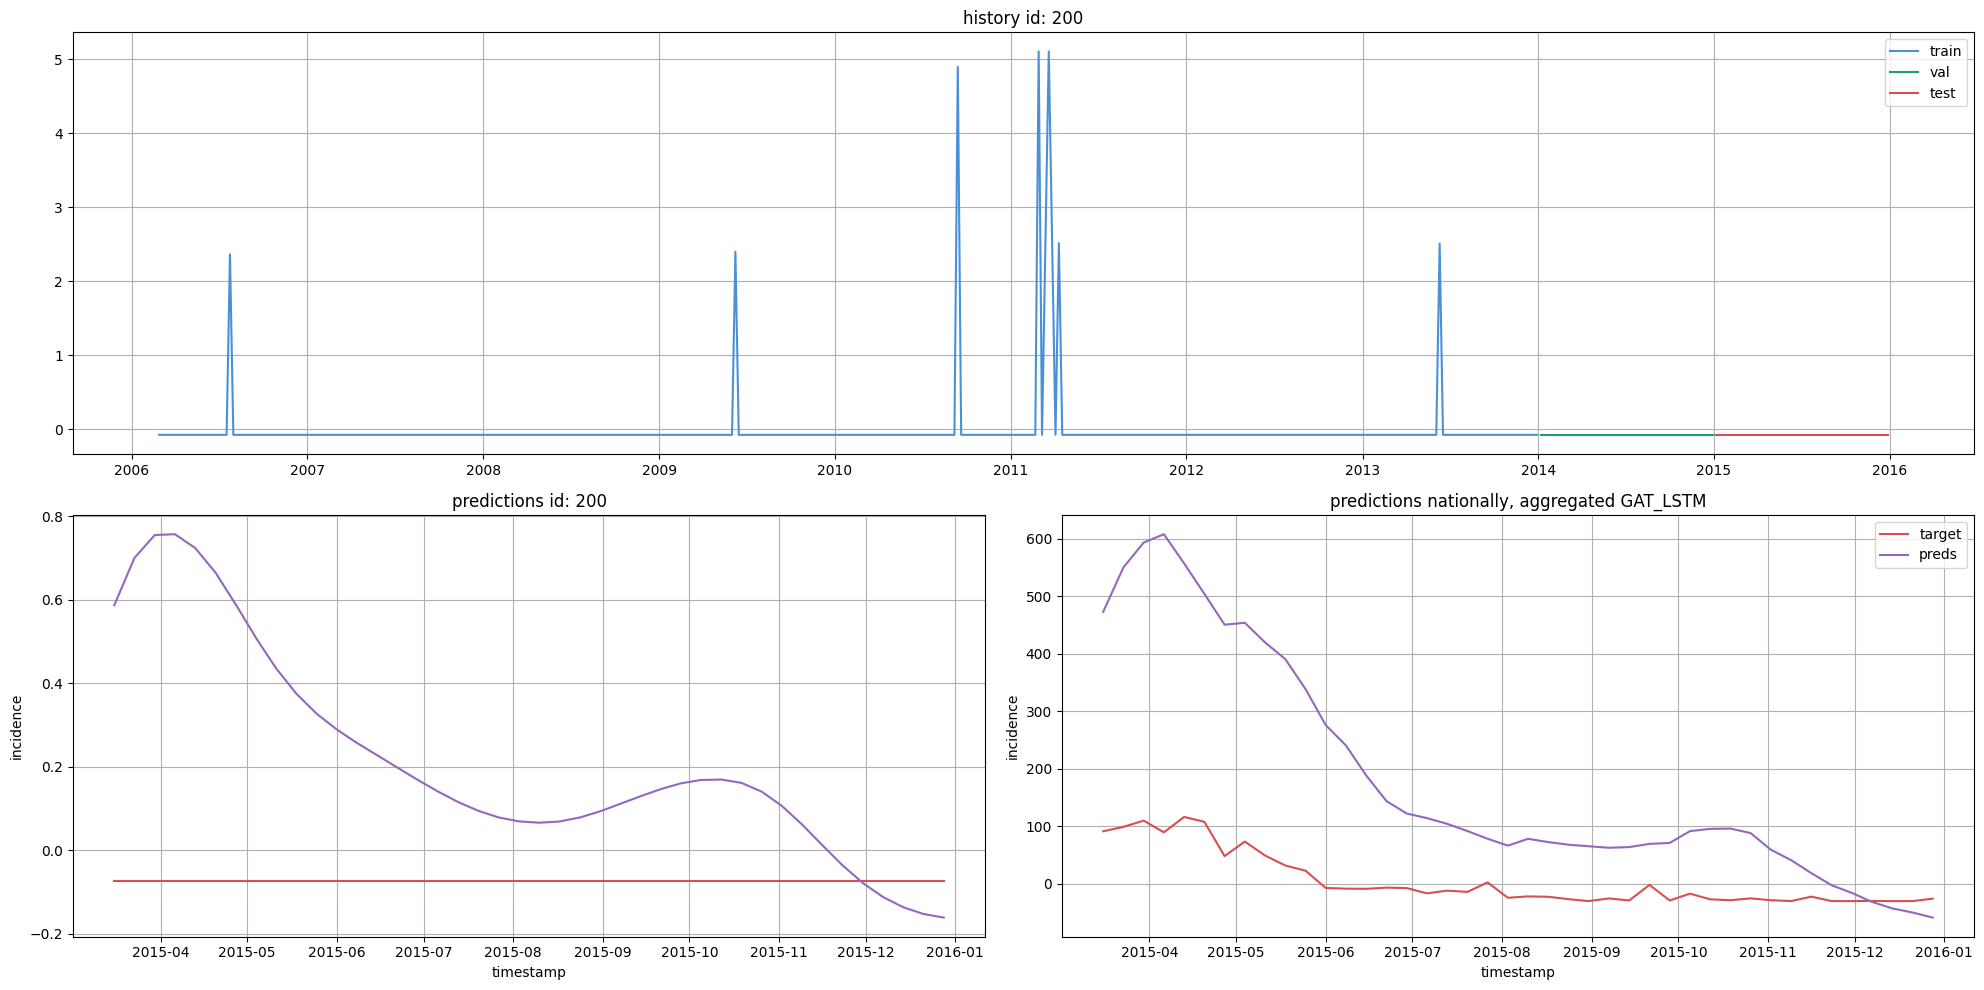

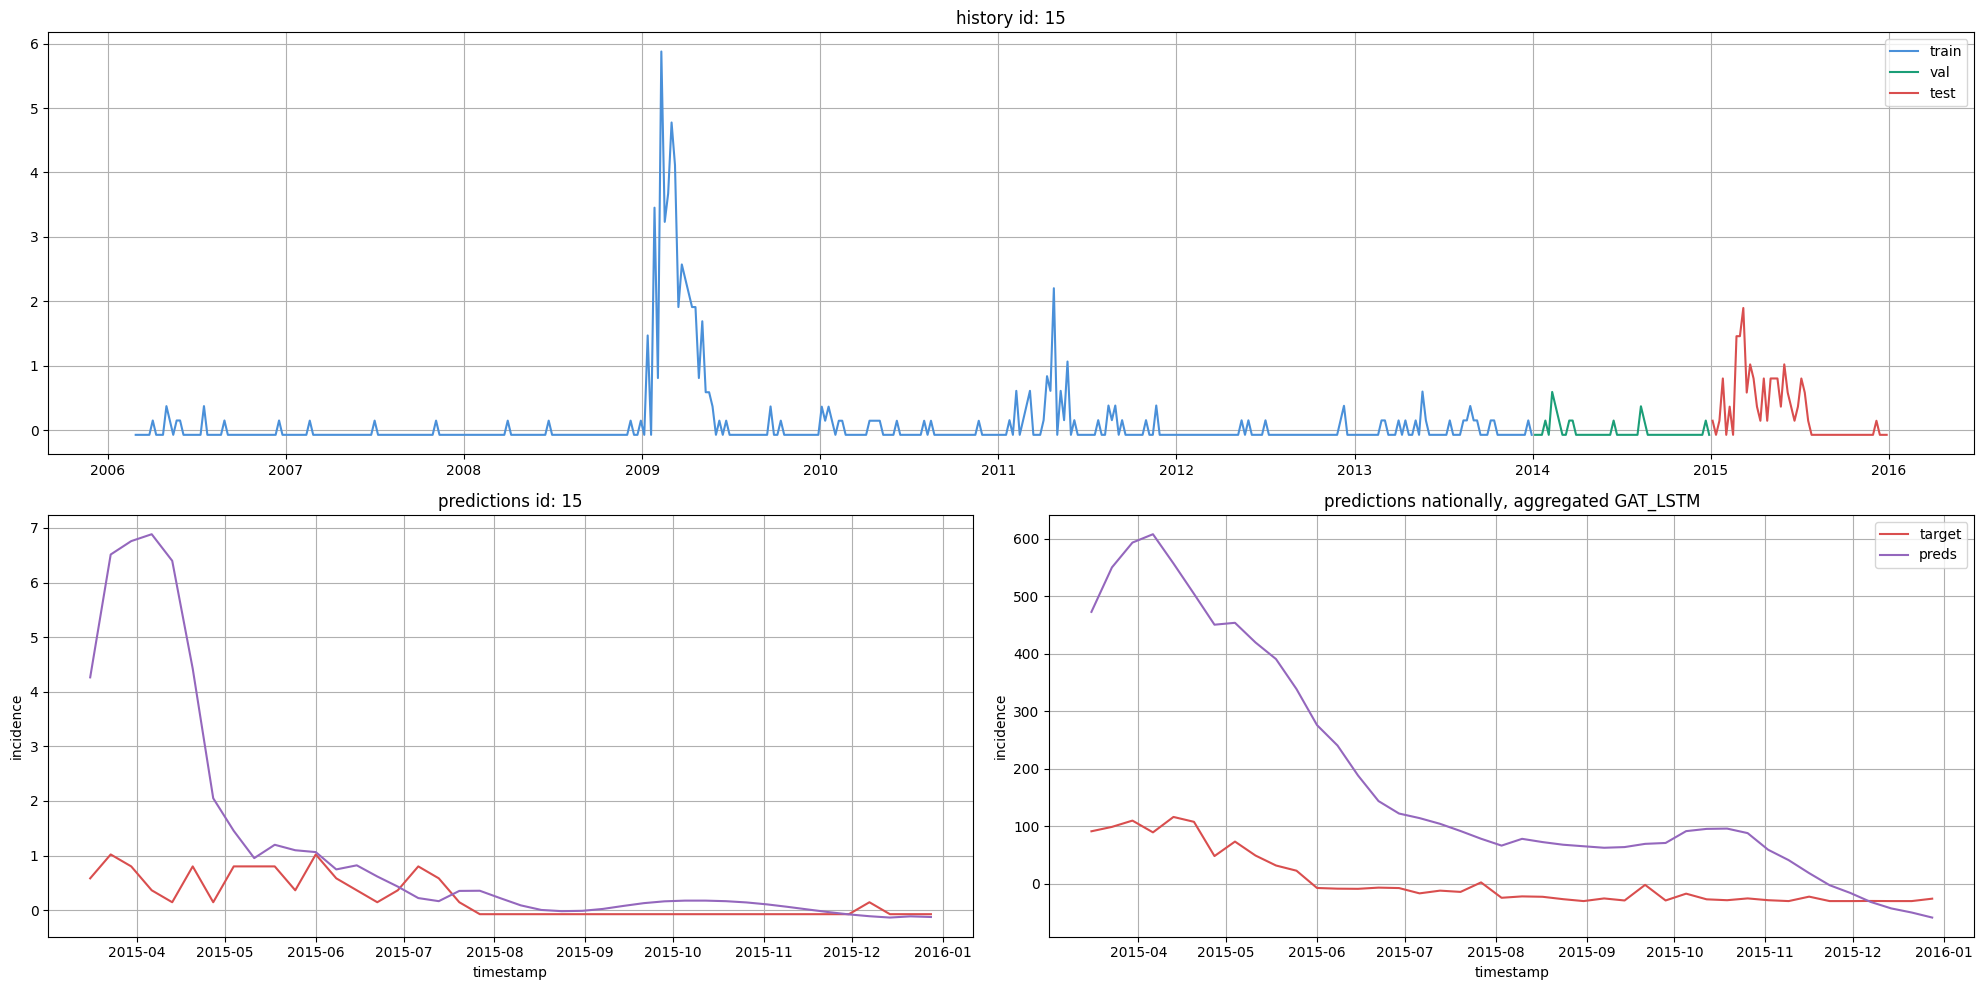

In [45]:
from src.dataloading.gnndataloader import GNNDataLoader
from src.models.gat_lstm_cleaned import GATLSTMModel_Cleaned

n_epochs = 25

dataloader_NodeLSTM = GNNDataLoader(epidata_lag1).retrieve_graph('identity_graph').construct_dataloaders(periods = 10)
gatlstm_model = GATLSTMModel_Cleaned(dataloader_NodeLSTM)

gatlstm_model.set_model_hparams(gat_hidden_size=128, lstm_hidden_size = 256, num_heads = 4)

gatlstm_model.set_global_hparams(lr = 0.00005, 
                                  n_epochs = n_epochs,     
                                  optimizer='adam', 
                                  scheduler='step',
                                  scheduler_kwargs={'step_size': 15,
                                                    'gamma' : 0.8},
                                loss = 'spike_weighted_mse',
                                min_delta = 1e-4
                                  )

gatlstm_model.train()
gatlstm_model.forecast()
gatlstm_model.show_forecasts(391)
gatlstm_model.show_forecasts(200)
gatlstm_model.show_forecasts(15)

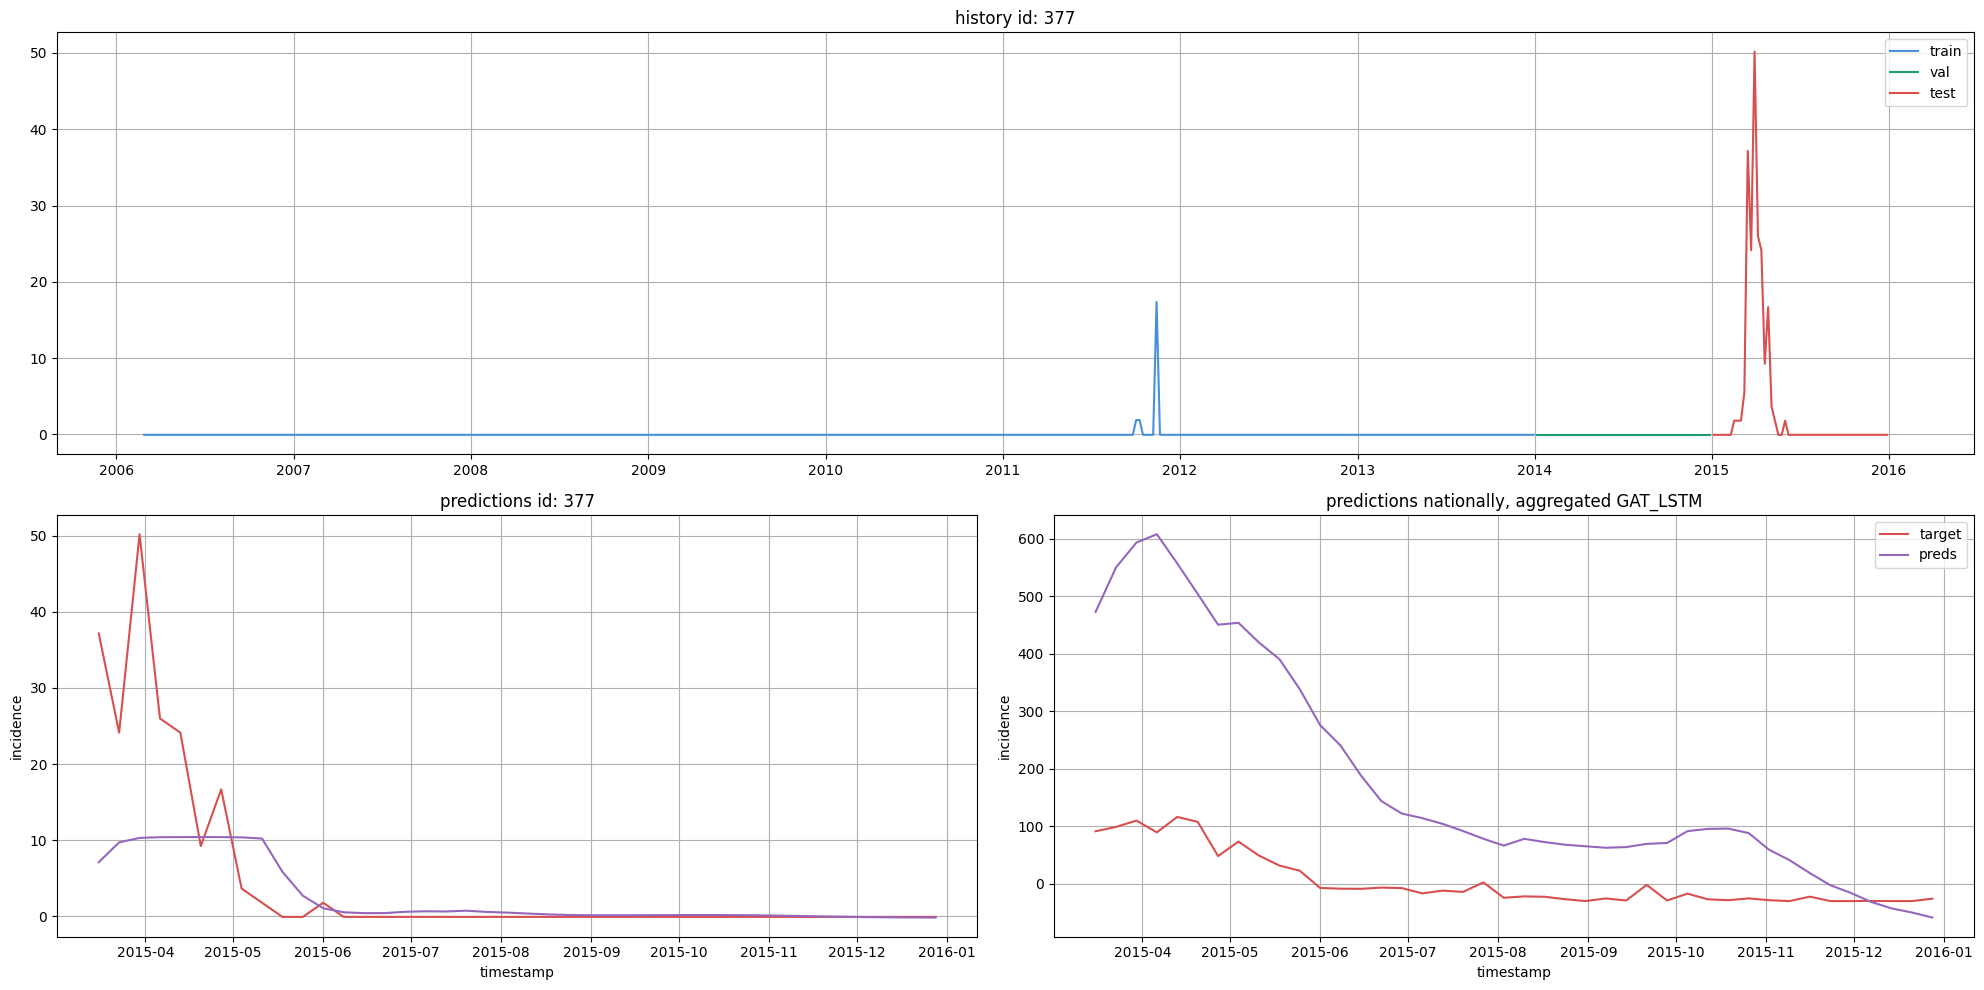

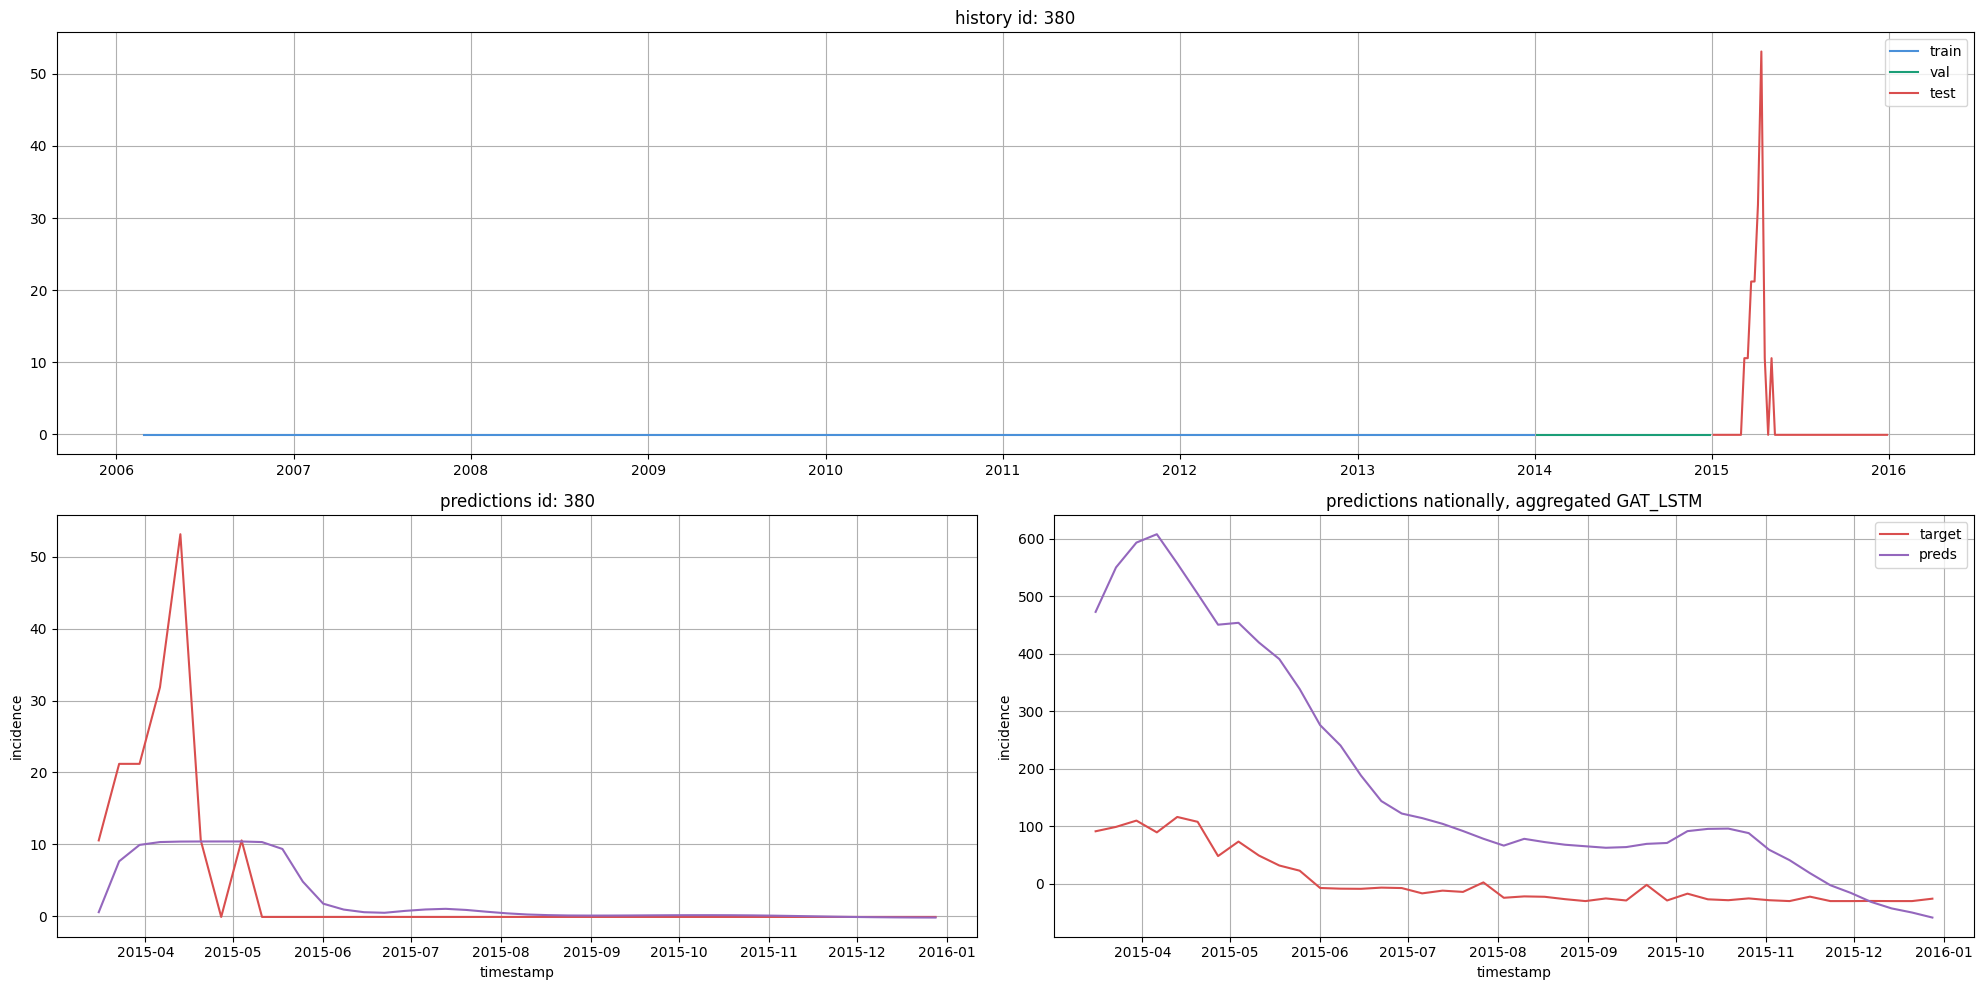

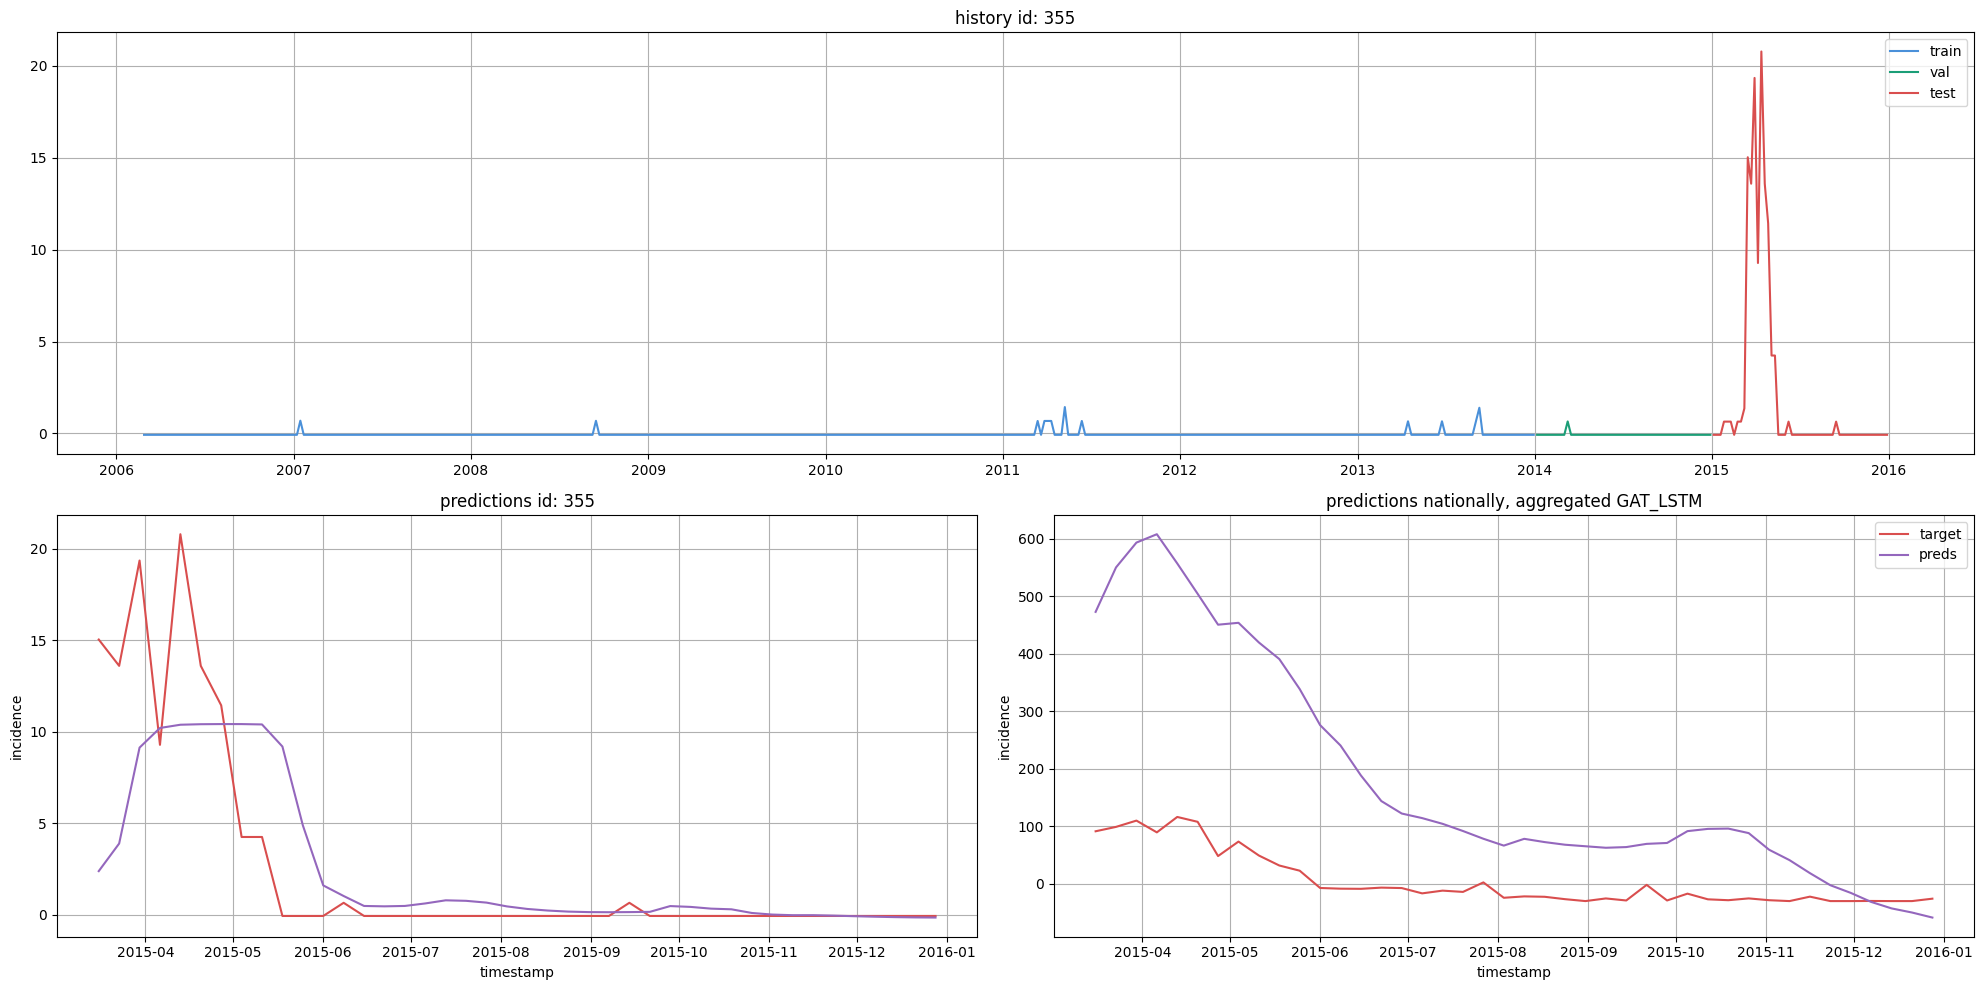

In [46]:
gatlstm_model.show_forecasts(377)
gatlstm_model.show_forecasts(380)
gatlstm_model.show_forecasts(355)

/home/de-schrijvers/projects/influenza/src/dataloading/gnndataloader.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_index = torch.load(graphpath + '_edge_index.pt

Epoch 0 train MSE: 38.7424, val MSE: 2.3832 ✓ (new best)
Epoch 1 train MSE: 36.5443, val MSE: 2.7567 (patience: 1/15)
Epoch 2 train MSE: 35.5823, val MSE: 2.7876 (patience: 2/15)
Epoch 3 train MSE: 36.0460, val MSE: 1.7669 ✓ (new best)
Epoch 4 train MSE: 34.8201, val MSE: 1.4965 ✓ (new best)
Epoch 5 train MSE: 33.7829, val MSE: 1.0498 ✓ (new best)
Epoch 6 train MSE: 34.2461, val MSE: 1.0485 ✓ (new best)
Epoch 7 train MSE: 32.7489, val MSE: 1.0427 ✓ (new best)
Epoch 8 train MSE: 31.7454, val MSE: 1.0358 ✓ (new best)
Epoch 9 train MSE: 31.7130, val MSE: 1.2799 (patience: 1/15)
Epoch 10 train MSE: 32.5428, val MSE: 1.3760 (patience: 2/15)
Epoch 11 train MSE: 31.4230, val MSE: 1.3281 (patience: 3/15)
Epoch 12 train MSE: 30.8823, val MSE: 1.0721 (patience: 4/15)
Epoch 13 train MSE: 29.5750, val MSE: 1.0521 (patience: 5/15)
Epoch 14 train MSE: 28.2947, val MSE: 1.1576 (patience: 6/15)
Epoch 15 train MSE: 27.6072, val MSE: 1.1304 (patience: 7/15)
Epoch 16 train MSE: 27.4968, val MSE: 1.1515 (

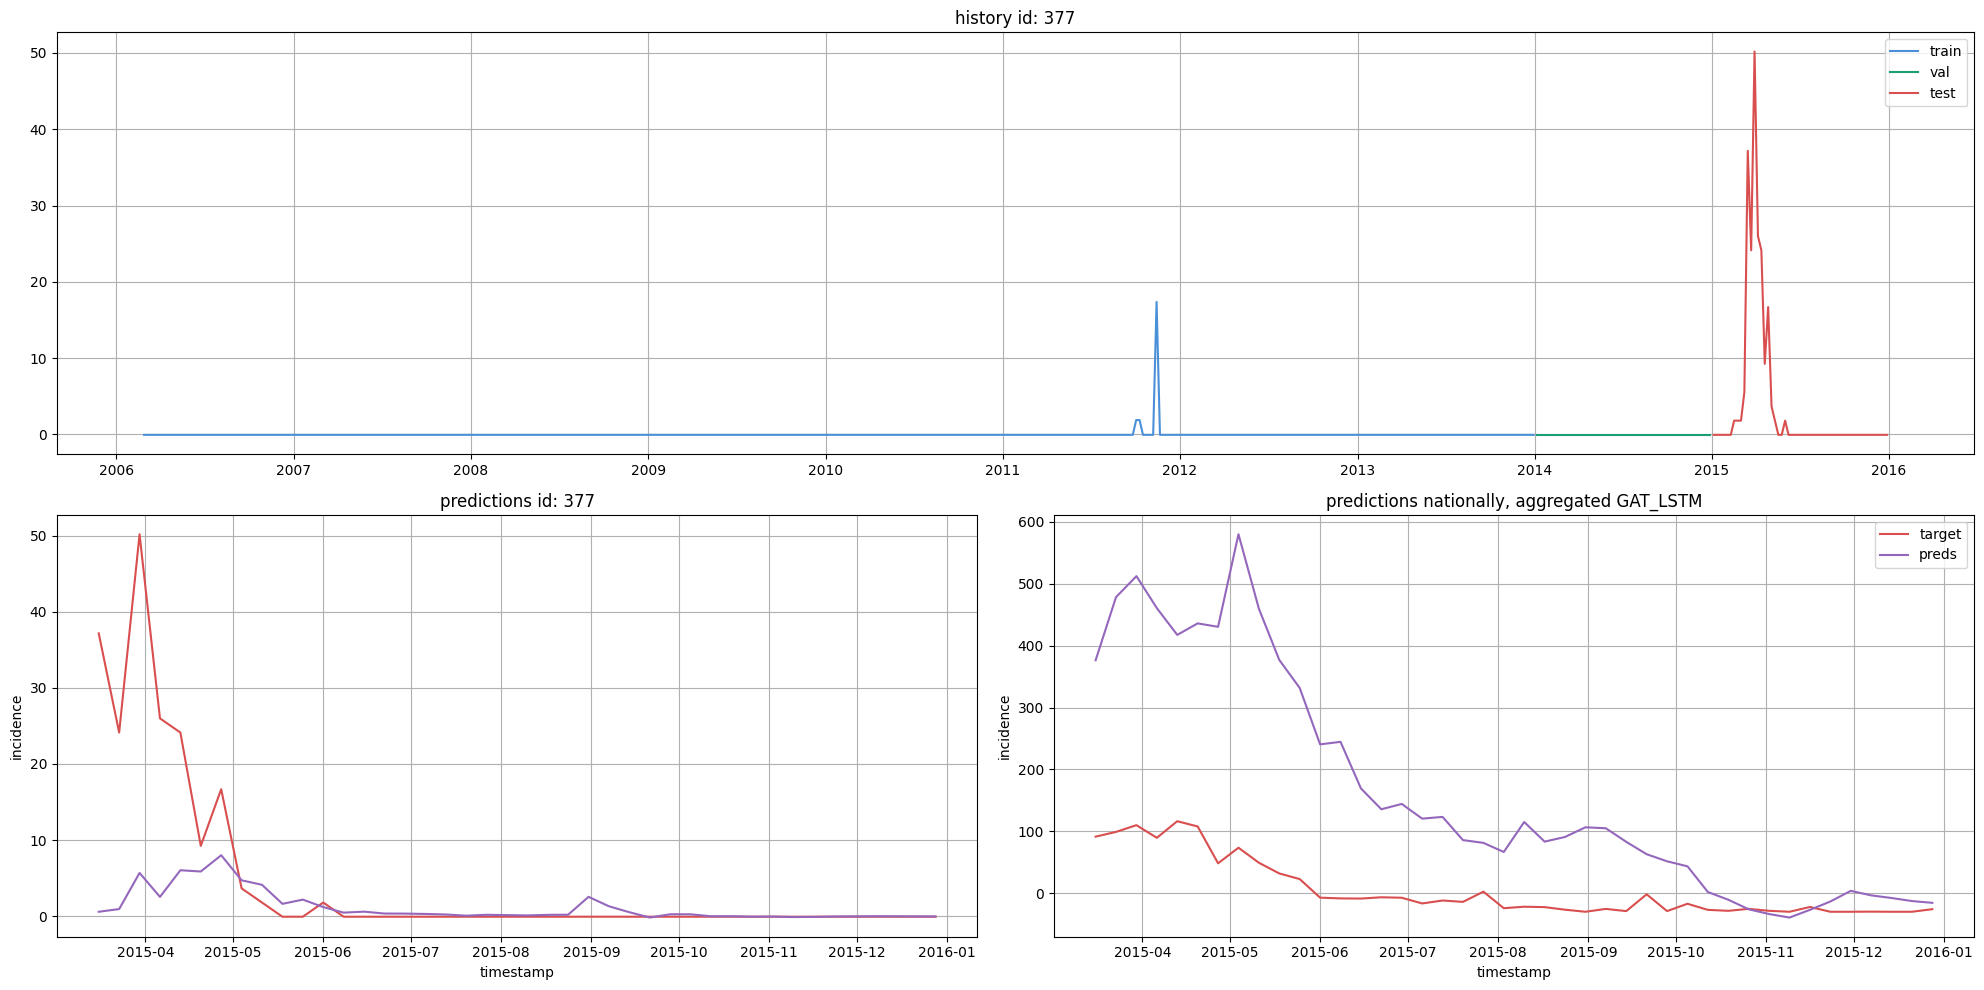

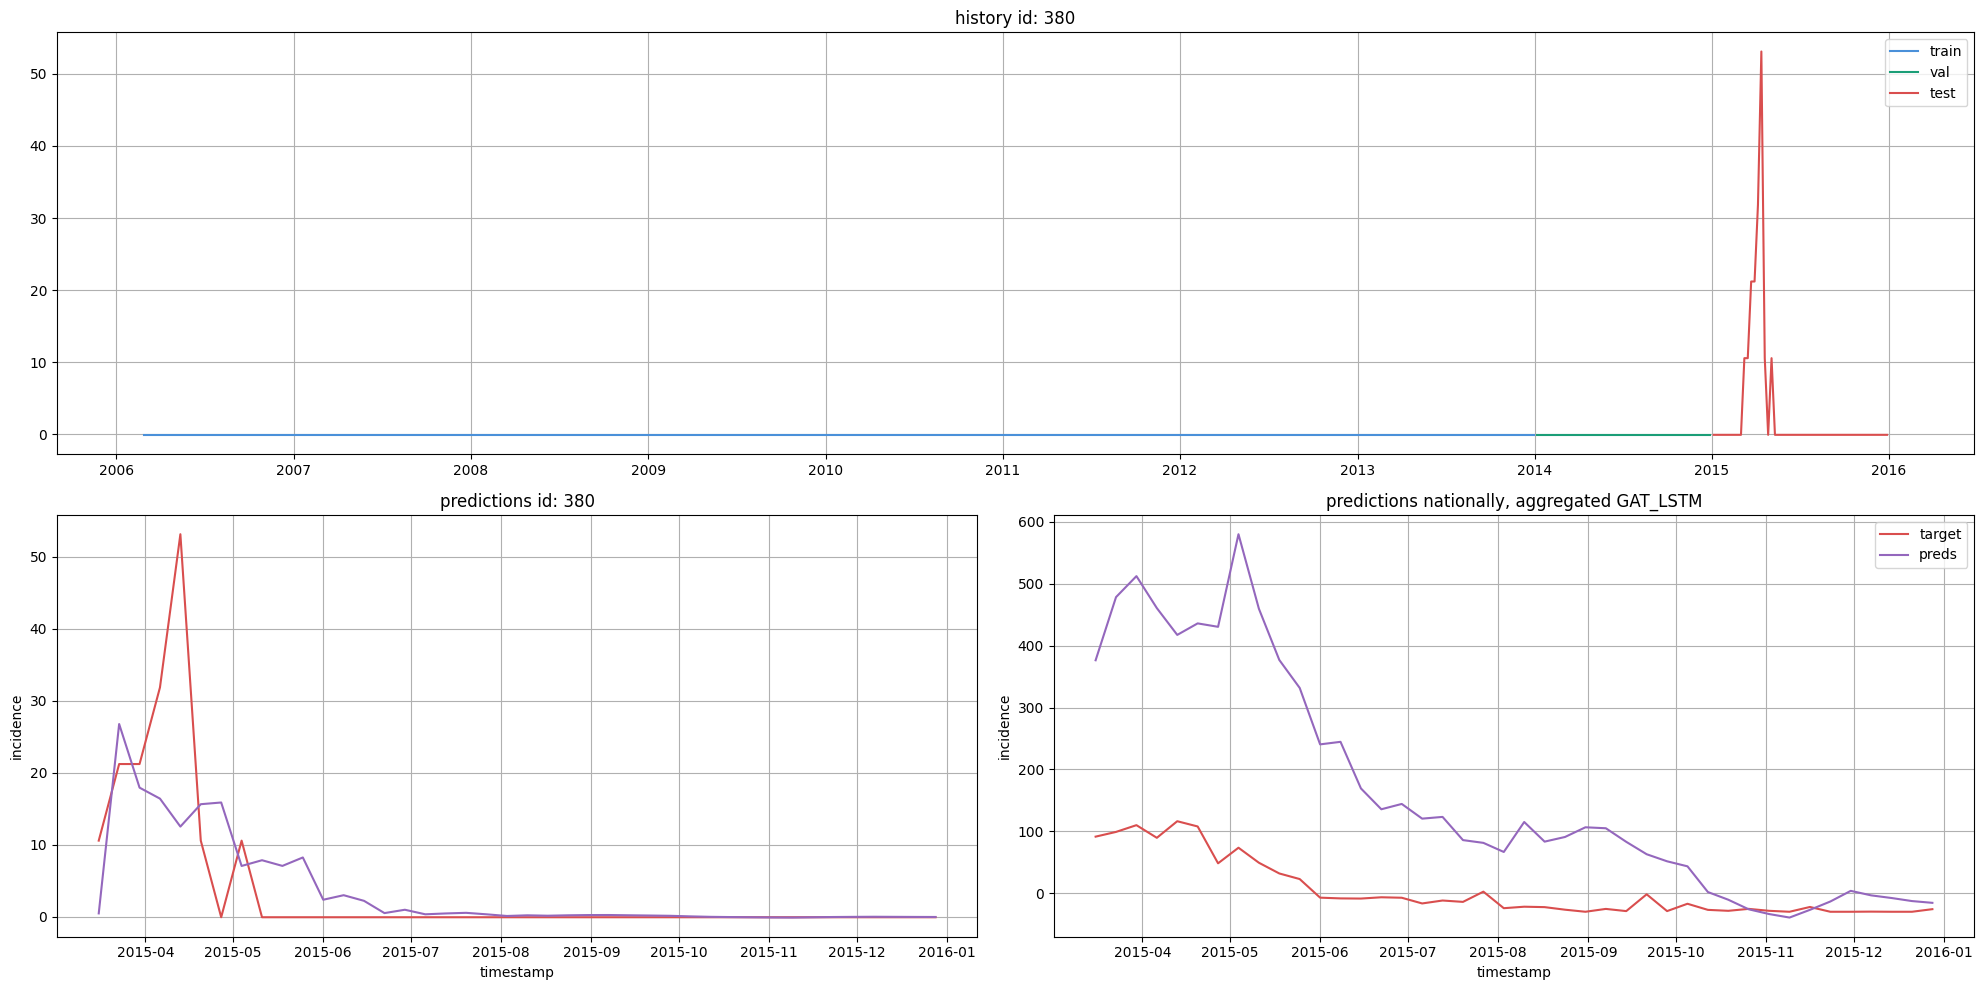

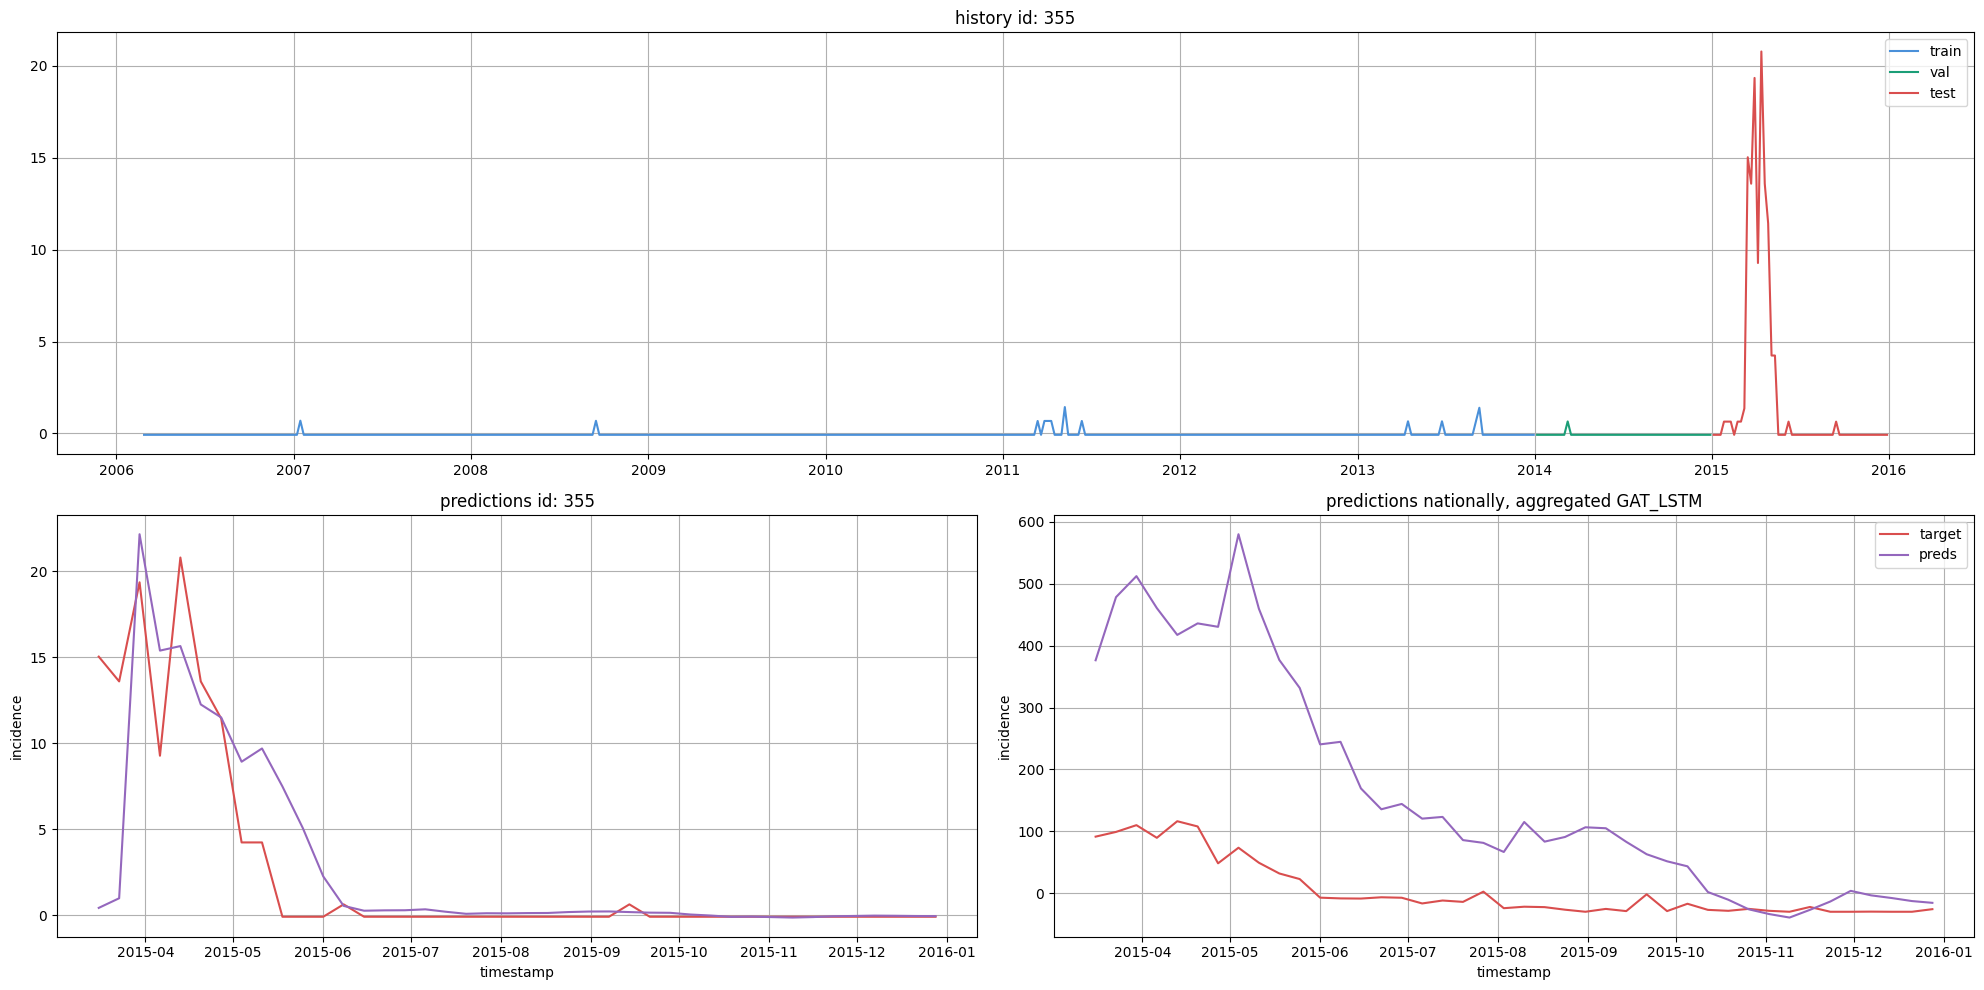

In [50]:
from src.dataloading.gnndataloader import GNNDataLoader
from src.models.gat_lstm_cleaned import GATLSTMModel_Cleaned

n_epochs = 25

dataloader_NodeLSTM = GNNDataLoader(epidata_lag1).retrieve_graph('boolean_neighbors').construct_dataloaders(periods = 10)
gatlstm_model = GATLSTMModel_Cleaned(dataloader_NodeLSTM)

gatlstm_model.set_model_hparams(gat_hidden_size=128, lstm_hidden_size = 256, num_heads = 4)

gatlstm_model.set_global_hparams(lr = 0.0005, 
                                  n_epochs = n_epochs,     
                                  optimizer='adam', 
                                  scheduler='step',
                                  scheduler_kwargs={'step_size': 15,
                                                    'gamma' : 0.8},
                                loss = 'spike_weighted_mse',
                                min_delta = 1e-4
                                  )

gatlstm_model.train()
gatlstm_model.forecast()
gatlstm_model.show_forecasts(377)
gatlstm_model.show_forecasts(380)
gatlstm_model.show_forecasts(355)